# 10. 演習解答

| 層 | セクション |
|---|---|
| — | 01〜08 章 演習の解答例 |

> 各章の演習を `laplace_book` と SymPy で解いた解答集(付録)。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## このノートについて

01〜08 章の演習の **解答例**。各章 1 セルで代表的な問いを `laplace_book` と SymPy で解く。

## 01 章 — 半減期と複素周波数

In [2]:
# Half-life: e^{sigma*T}=1/2  ->  sigma = -ln2 / T_half
T_half = 5.0
sigma = -np.log(2) / T_half
print("sigma =", sigma, " check e^{sigma*T_half} =", np.exp(sigma * T_half))   # 0.5

sigma = -0.13862943611198905  check e^{sigma*T_half} = 0.5


## 02 章 — 線形性・周波数シフト・初期値定理

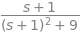

initial value of cos(wt): 1


In [3]:
display(L(3 - 2 * sp.exp(-t)))               # 3/s - 2/(s+1)
display(L(sp.exp(-t) * sp.cos(3 * t)))       # (s+1)/((s+1)^2 + 9)
w = sp.symbols("omega", positive=True)
print("initial value of cos(wt):", sp.limit(s * L(sp.cos(w * t)), s, sp.oo))   # 1

## 03 章 — 逆変換(単純極・重根・複素極)

In [4]:
for F in [(2 * s + 1) / (s**2 + s), 1 / (s + 2) ** 3, s / (s**2 + 4)]:
    display(sp.simplify(Linv(F)))            # 1 + e^{-t};  t^2 e^{-2t}/2;  cos(2t)

## 04 章 — ODE と共振

In [5]:
display(Linv(3 / (s + 2)))                   # y'+2y=0, y(0)=3 -> 3 e^{-2t}
# y'' + y = sin t, zero IC: Y = 1/(s^2+1)^2 -> resonance (amplitude grows with t)
display(sp.simplify(Linv(1 / (s**2 + 1) ** 2)))   # (sin t - t cos t)/2

## 05 章 — インパルス応答とステップ応答

In [6]:
display(Linv(1 / (s + 2)))                       # impulse response: e^{-2t}
display(sp.simplify(Linv(1 / (s * (s + 2)))))    # step response: (1 - e^{-2t})/2

## 06 章 — 極・安定性と零点の役割

In [7]:
H = systems.tf([1.0], [1.0, 4.0, 13.0])       # 1/((s+2)^2 + 9): poles -2 +/- 3i
print("poles:", systems.poles(H))
H2 = systems.tf([1.0, 1.0], [1.0, 4.0, 13.0]) # same poles, extra zero at -1
print("stability without/with zero:", systems.classify_stability(H), systems.classify_stability(H2))

poles: [-2.+3.j -2.-3.j]
stability without/with zero: stable stable


## 07 章 — 時定数とフィードバックの定常偏差

In [8]:
# Halving tau = RC moves the pole left (faster response).
print("tau=1.0ms pole:", systems.poles(circuits.rc_lowpass(1000.0, 1e-6)))
print("tau=0.5ms pole:", systems.poles(circuits.rc_lowpass(500.0, 1e-6)))
# PI control K(s)=2 + 1/s on plant 1/(s+1): closed-loop DC gain = 1 -> zero steady-state step error.
plant = systems.tf([1.0], [1.0, 1.0])
Kpi = systems.tf([2.0, 1.0], [1.0, 0.0])
closed = systems.feedback(systems.series(plant, Kpi))
print("PI closed-loop DC gain:", systems.dc_gain(closed), "-> steady-state step error = 0")

tau=1.0ms pole: [-1000.]
tau=0.5ms pole: [-2000.]
PI closed-loop DC gain: 1.0 -> steady-state step error = 0


## 08 章 — 永久債・ガンマ分布

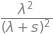

In [9]:
c0, r = sp.symbols("c0 r", positive=True)
display(sp.laplace_transform(c0, t, r, noconds=True))   # c0/r  (perpetuity present value)
lam = sp.symbols("lambda", positive=True)
display(L(lam**2 * t * sp.exp(-lam * t)))               # lambda^2/(s+lambda)^2  (Gamma, k=2)

> すべて記号/数値で再現可能。詳しい解説は各章本文を参照。